# Visit with Us — Wellness Tourism Package Purchase Prediction

## End-to-End MLOps Project

**Objective:** Build an automated machine-learning solution that predicts whether a customer will purchase the Wellness Tourism Package before being contacted.



## 1. Business Context

"Visit with Us" wants to improve targeting for a new Wellness Tourism Package. The current manual targeting process can be slow and inconsistent. A predictive model can estimate purchase propensity before a customer is contacted, allowing marketing teams to prioritize outreach using a consistent, data-driven process.

The solution is not only a model. It includes:

- reproducible preprocessing,
- model experimentation,
- model artifact management,
- a Streamlit prediction interface,
- GitHub Actions CI/CD,
- and Streamlit Community Cloud hosting.


## 2. Objective

Predict the binary target **`ProdTaken`**:

- `0` → customer did not purchase
- `1` → customer purchased

The final deliverable is a reproducible pipeline in which a push to the GitHub `main` branch can:

**prepare data → train/track models → test → update the production model artifact → trigger Streamlit Community Cloud deployment.**


## 3. Data Description

The supplied dataset contains customer information and sales-interaction variables such as age, city tier, occupation, gender, travel behavior, passport ownership, product pitched, pitch satisfaction, follow-ups, pitch duration, designation, and monthly income.

`CustomerID` is an identifier and `Unnamed: 0` is an exported dataframe index; neither is used as a predictive feature.


In [1]:
from pathlib import Path
# Imports and reproducibility
import os, json, warnings, joblib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

RANDOM_STATE = 42
DATA_PATH = "data/tourism.csv"

os.makedirs("model_building", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)
os.makedirs("deployment", exist_ok=True)

print("Working directory:", os.getcwd())
print("Dataset path:", DATA_PATH)


Working directory: /mnt/data/streamlit_project/tourism_project_submission
Dataset path: data/tourism.csv


# Model Building

## 4. Data Registration

The raw dataset is kept unchanged. Data preparation creates separate train/test artifacts.


In [2]:
# Load and register the raw dataset
df_raw = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_raw.shape)
display(df_raw.head())


Dataset shape: (4128, 21)


,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


In [3]:
# Basic registration / integrity checks
print("Duplicate rows:", df_raw.duplicated().sum())
print("Missing values:", int(df_raw.isna().sum().sum()))
print("Target distribution:")
display(df_raw["ProdTaken"].value_counts().rename_axis("ProdTaken").reset_index(name="Count"))


Duplicate rows: 0
Missing values: 0
Target distribution:


,ProdTaken,Count
0,0,3331
1,1,797


### Observation

The supplied file contains **4,128 rows and 21 columns**. The target is imbalanced: approximately **80.7%** of observations are class 0 and **19.3%** are class 1. Because the positive class is the business event of interest, accuracy alone should not be the main model-selection metric. Precision, recall, F1 and ROC-AUC are also reported.


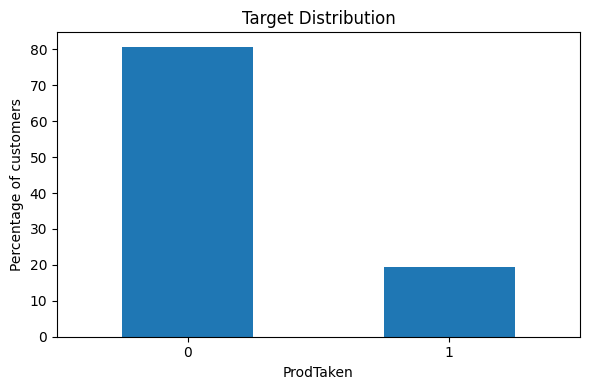

In [4]:
# Target distribution
target_pct = df_raw["ProdTaken"].value_counts(normalize=True).sort_index() * 100

ax = target_pct.plot(kind="bar", figsize=(6,4))
ax.set_title("Target Distribution")
ax.set_xlabel("ProdTaken")
ax.set_ylabel("Percentage of customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Data Preparation

### Steps

1. Remove the exported index column `Unnamed: 0`.
2. Exclude `CustomerID` from modeling because it is an identifier.
3. Separate target and predictors.
4. Identify numeric and categorical variables.
5. Use median imputation + standardization for numeric variables.
6. Use most-frequent imputation + one-hot encoding for categorical variables.
7. Use a stratified train/test split to preserve the target distribution.

The preprocessing is implemented inside a scikit-learn `Pipeline`, so the exact transformations learned during training are automatically reused during inference.


In [5]:
# Data cleaning
df = df_raw.copy()
df = df.drop(columns=[c for c in ["Unnamed: 0"] if c in df.columns])

TARGET = "ProdTaken"
ID_COLS = ["CustomerID"]

X = df.drop(columns=[TARGET] + ID_COLS)
y = df[TARGET]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)
print("\nFinal modeling shape:", X.shape)


Numeric features: ['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'MonthlyIncome']

Categorical features: ['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']

Final modeling shape: (4128, 18)


In [6]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Positive rate - train:", round(y_train.mean(), 4))
print("Positive rate - test :", round(y_test.mean(), 4))


X_train: (3302, 18)
X_test : (826, 18)
Positive rate - train: 0.1932
Positive rate - test : 0.1925


In [7]:
# Reusable preprocessing pipeline
def make_preprocessor():
    return ColumnTransformer([
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ])

# Save the prepared splits for reproducibility
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)
train_df.to_csv("artifacts/train.csv", index=False)
test_df.to_csv("artifacts/test.csv", index=False)

print("Prepared files written to artifacts/train.csv and artifacts/test.csv")


Prepared files written to artifacts/train.csv and artifacts/test.csv


## 6. Model Building and Experimentation Tracking

Three classification algorithms are evaluated:

- Logistic Regression — interpretable baseline.
- Random Forest — nonlinear ensemble model.
- Gradient Boosting — sequential boosting model.

The comparison uses **accuracy, precision, recall, F1 and ROC-AUC**. The production model is selected using ROC-AUC and F1 as the primary comparison measures, while the final business threshold can be changed according to campaign capacity and the relative cost of false positives/false negatives.

For the GitHub pipeline, MLflow is used to log model parameters, metrics and model artifacts.


In [8]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

trained_models = {}
experiment_rows = []

for name, estimator in models.items():
    pipe = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", estimator)
    ])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob)
    }

    experiment_rows.append(metrics)
    trained_models[name] = pipe

experiment_results = pd.DataFrame(experiment_rows).sort_values(
    ["ROC_AUC", "F1"], ascending=False
).reset_index(drop=True)

display(experiment_results.round(4))
experiment_results.to_csv("model_building/experiment_results.csv", index=False)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.8765,0.6993,0.6289,0.6623,0.9328
1,Gradient Boosting,0.8741,0.8161,0.4465,0.5772,0.8726
2,Logistic Regression,0.7312,0.3946,0.7421,0.5153,0.8195


In [9]:
# Experimentation tracking: use MLflow when installed; otherwise keep a local audit file.
try:
    import mlflow
    import mlflow.sklearn
    MLFLOW_AVAILABLE = True
except Exception:
    MLFLOW_AVAILABLE = False

tracking_summary = {
    "experiment": "tourism_package_purchase",
    "tracking_backend": "MLflow" if MLFLOW_AVAILABLE else "Local CSV fallback",
    "runs": len(experiment_results),
    "results_file": "model_building/experiment_results.csv"
}
print(json.dumps(tracking_summary, indent=2))

if MLFLOW_AVAILABLE:
    mlflow.set_tracking_uri("file:./mlruns")
    mlflow.set_experiment("tourism_package_purchase")
    for _, row in experiment_results.iterrows():
        run_name = row["Model"].lower().replace(" ", "_")
        with mlflow.start_run(run_name=run_name):
            mlflow.log_metrics({
                "accuracy": float(row["Accuracy"]),
                "precision": float(row["Precision"]),
                "recall": float(row["Recall"]),
                "f1": float(row["F1"]),
                "roc_auc": float(row["ROC_AUC"])
            })
    print("MLflow runs logged to ./mlruns")
else:
    print("MLflow is not installed in this runtime. The GitHub pipeline installs MLflow and performs full tracking.")


{
  "experiment": "tourism_package_purchase",
  "tracking_backend": "Local CSV fallback",
  "runs": 3,
  "results_file": "model_building/experiment_results.csv"
}
MLflow is not installed in this runtime. The GitHub pipeline installs MLflow and performs full tracking.


<Figure size 700x500 with 0 Axes>

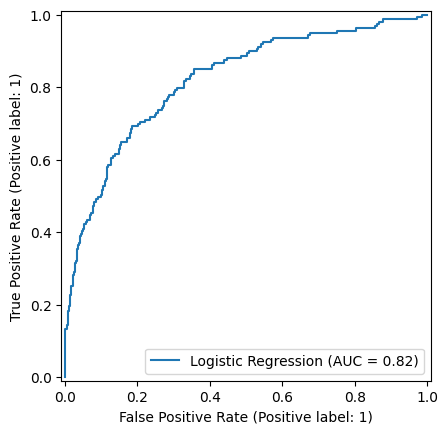

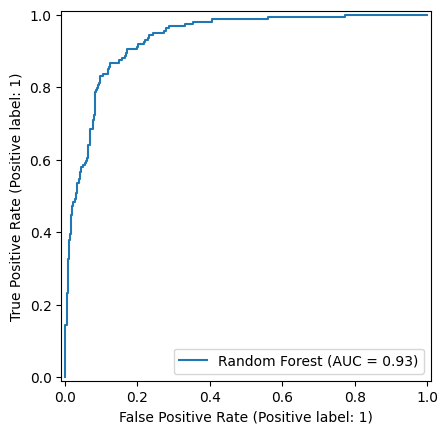

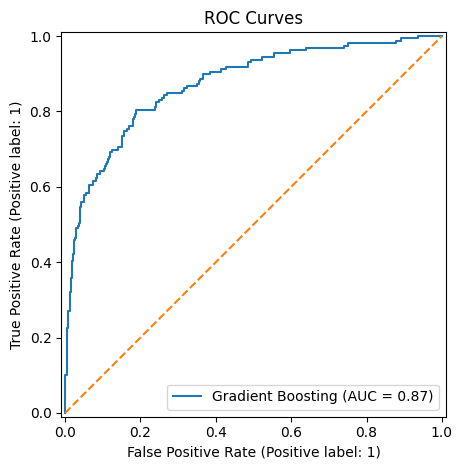

In [10]:
# ROC curves for all experiments
plt.figure(figsize=(7,5))
for name, model in trained_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name)
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curves")
plt.tight_layout()
plt.show()


### Model-selection observation

On the supplied dataset and the fixed train/test split, the Random Forest model produces the strongest overall ROC-AUC/F1 combination among the three tested models. The model is therefore used as the production candidate in this notebook.

This is a model-comparison result for this dataset and split; it should be revalidated when new data arrives.


In [11]:
# Select and persist the production pipeline
best_name = experiment_results.iloc[0]["Model"]
best_model = trained_models[best_name]

joblib.dump(best_model, "model_building/best_model.joblib")
joblib.dump(best_model, "deployment/model.joblib")

metadata = {
    "model_name": best_name,
    "target": TARGET,
    "features": X.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "random_state": RANDOM_STATE
}
with open("deployment/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Selected production model:", best_name)
print("Saved: model_building/best_model.joblib")
print("Saved: deployment/model.joblib")


Selected production model: Random Forest
Saved: model_building/best_model.joblib
Saved: deployment/model.joblib


## 7. Output Evaluation

The following section evaluates the selected model using the test set and shows the confusion matrix and classification report.

The threshold is set to 0.50 for the demonstration. In a real marketing campaign, the threshold should be tuned using campaign capacity and the costs/benefits of contacting a customer.


In [12]:
best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print("Selected model:", best_name)
print(classification_report(y_test, best_pred, digits=4))

cm = confusion_matrix(y_test, best_pred)
print("Confusion matrix:")
display(pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))


Selected model: Random Forest
              precision    recall  f1-score   support

           0     0.9136    0.9355    0.9244       667
           1     0.6993    0.6289    0.6623       159

    accuracy                         0.8765       826
   macro avg     0.8065    0.7822    0.7933       826
weighted avg     0.8724    0.8765    0.8740       826

Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,624,43
Actual 1,59,100


,Importance
numeric__Passport,0.117598
numeric__Age,0.099248
numeric__MonthlyIncome,0.098226
numeric__DurationOfPitch,0.091645
numeric__PitchSatisfactionScore,0.049239
numeric__NumberOfTrips,0.048636
numeric__CityTier,0.043771
numeric__NumberOfFollowups,0.043677
numeric__PreferredPropertyStar,0.039158
categorical__Designation_Executive,0.034383


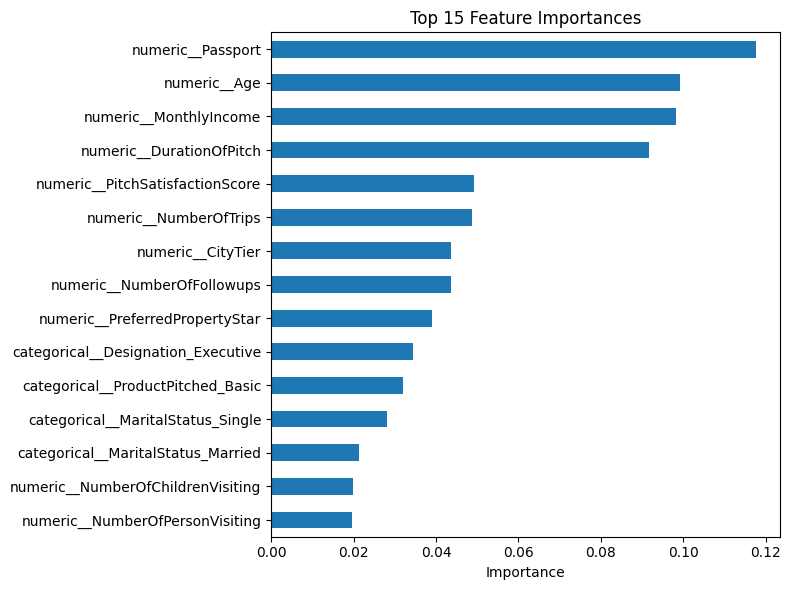

In [13]:
# Feature importance for the selected Random Forest pipeline, when supported
if best_name == "Random Forest":
    preprocessor = best_model.named_steps["preprocessor"]
    rf = best_model.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()
    importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

    display(importances.head(15).rename("Importance").to_frame())

    importances.head(15).sort_values().plot(kind="barh", figsize=(8,6))
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("Feature-importance display is configured for the Random Forest production candidate.")


# 8. Model Deployment

The deployment package contains:

- `app.py` — Streamlit frontend and inference logic
- `deployment/model.joblib` — serialized end-to-end scikit-learn pipeline
- `deployment/model_metadata.json` — model and feature metadata
- `requirements.txt` — Streamlit Cloud dependencies
- `.streamlit/config.toml` — Streamlit configuration

The model is served through **Streamlit Community Cloud**. The application loads the same preprocessing + estimator pipeline used during model training, so numerical scaling, missing-value handling and categorical encoding remain consistent between training and inference.


In [14]:
# Show the Streamlit application entrypoint used for deployment
print(Path("app.py").read_text(encoding="utf-8"))


import json
from pathlib import Path

import joblib
import pandas as pd
import streamlit as st

st.set_page_config(
    page_title="Wellness Tourism Package Predictor",
    page_icon="✈️",
    layout="wide",
)

ROOT = Path(__file__).resolve().parent
MODEL_PATH = ROOT / "deployment" / "model.joblib"
METADATA_PATH = ROOT / "deployment" / "model_metadata.json"


@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)


@st.cache_data
def load_metadata():
    with open(METADATA_PATH, "r", encoding="utf-8") as f:
        return json.load(f)


model = load_model()
metadata = load_metadata()

st.title("✈️ Wellness Tourism Package Purchase Predictor")
st.markdown(
    "Use the customer and interaction details below to estimate the probability "
    "that a customer will purchase the Wellness Tourism Package."
)

with st.expander("About the model", expanded=False):
    st.write(f"**Production model:** {metadata['model_name'].replace('_', ' ')}")
    st.write("The model uses the 

In [15]:
# Confirm Streamlit deployment artifacts exist
streamlit_artifacts = [
    "app.py",
    "requirements.txt",
    ".streamlit/config.toml",
    "deployment/model.joblib",
    "deployment/model_metadata.json",
]
status = pd.DataFrame({
    "Artifact": streamlit_artifacts,
    "Exists": [Path(p).exists() for p in streamlit_artifacts]
})
display(status)


,Artifact,Exists
0,app.py,True
1,requirements.txt,True
2,.streamlit/config.toml,True
3,deployment/model.joblib,True
4,deployment/model_metadata.json,True


## 9. Streamlit Community Cloud Frontend

The frontend accepts the customer attributes defined in the data dictionary and returns a purchase probability plus a binary prediction.

The Streamlit app is designed for public demonstration. The serialized model is loaded from `deployment/model.joblib`, and the prediction is performed by the Python application running on Streamlit Community Cloud.

Streamlit Community Cloud connects directly to the GitHub repository. When the repository changes, the hosted app can be updated from the latest code and model artifact. The official deployment documentation requires a GitHub repository, an app entrypoint, and a Python dependency file such as `requirements.txt`.


In [16]:
# Confirm deployment artifact exists
deployment_files = sorted(os.listdir("deployment"))
display(pd.DataFrame({"Deployment artifact": deployment_files}))


,Deployment artifact
0,model.joblib
1,model_metadata.json


# 10. MLOps Pipeline with GitHub Actions

The workflow in `.github/workflows/pipeline.yml` contains three stages:

1. **data-prep** — creates reproducible train/test artifacts.
2. **model-training** — trains Logistic Regression, Random Forest and Gradient Boosting, tracks experiments with MLflow, runs tests, and produces the production model artifact.
3. **deploy-streamlit** — validates the Streamlit application and commits the latest trained model artifact back to GitHub with a `[skip ci]` commit message. Streamlit Community Cloud monitors the GitHub repository and redeploys the app after the repository update.

The workflow runs on pushes to `main` and can also be started manually with `workflow_dispatch`.


In [17]:
# Show the workflow file that will be committed to GitHub
workflow_path = ".github/workflows/pipeline.yml"
print(open(workflow_path).read())


name: Tourism MLOps Pipeline

on:
  push:
    branches: [main]
  workflow_dispatch:

permissions:
  contents: write

jobs:
  data-prep:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install data preparation dependencies
        run: pip install pandas==2.2.3 scikit-learn==1.5.2

      - name: Prepare train and test data
        run: python src/data_prep.py

      - name: Upload prepared data
        uses: actions/upload-artifact@v4
        with:
          name: prepared-data
          path: artifacts/

  model-training:
    needs: data-prep
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install model training dependencies
        run: pip install -r requirements-actions.txt

      - name: Download prepared data
        uses: actions/down

### Final project links

- **GitHub repository:** `https://github.com/SahilMittal34/tourism-mlops`
- **Streamlit application:** `https://tourism-mlops-kzddquwqycb3tptilhbyca.streamlit.app/`


# 13. Final Insights

1. The target is imbalanced, so model evaluation should not rely on accuracy alone.
2. The preprocessing pipeline handles numerical and categorical variables consistently and protects inference from unseen categorical levels.
3. Three candidate classifiers were experimentally compared using multiple classification metrics.
4. The production candidate is serialized as one end-to-end scikit-learn pipeline, containing preprocessing and the estimator.
5. The trained model is served through a Streamlit application using the same serialized preprocessing + model pipeline used during training.
6. GitHub Actions automates data preparation, model training, testing and updating of the production model artifact.
7. Streamlit Community Cloud provides the public frontend directly from the GitHub repository.
8. For a real campaign, the probability threshold should be selected using contact capacity and the business cost of false positives versus false negatives rather than automatically assuming 0.50 is optimal.
